- Save figures as PDF
- Take out the figure title from the figures(keep it as caption in Latex)
- Font size: x and y axis size 24 bolded(x and y axis title mandatory)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pip install ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [ ]:
from ucimlrepo import fetch_ucirepo
# fetch dataset
statlog_german_credit_data = fetch_ucirepo(id=144)

# data (as pandas dataframes)
X = statlog_german_credit_data.data.features
y = statlog_german_credit_data.data.targets

# metadata
print(statlog_german_credit_data.metadata)

# variable information
print(statlog_german_credit_data.variables)
# Combine into one DataFrame
df = pd.concat([X, y], axis=1)

# Verify the shape (should have 21 columns: 20 features + 1 target)
print(df.shape)
df.head()

df.to_csv("/content/drive/MyDrive/Thesis/datasets/german_credit_raw.csv", index=False)

{'uci_id': 144, 'name': 'Statlog (German Credit Data)', 'repository_url': 'https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data', 'data_url': 'https://archive.ics.uci.edu/static/public/144/data.csv', 'abstract': 'This dataset classifies people described by a set of attributes as good or bad credit risks. Comes in two formats (one all numeric). Also comes with a cost matrix', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1000, 'num_features': 20, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Other', 'Marital Status', 'Age', 'Occupation'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1994, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5NC77', 'creators': ['Hans Hofmann'], 'intro_paper': None, 'additional_info': {'summary': 'Two datasets are provided.  the original dataset, in the form provided by

In [ ]:
# data mapping for simplicity
column_mapping = {
    "Attribute1": "checking_account_status",
    "Attribute2": "duration_months",
    "Attribute3": "credit_history",
    "Attribute4": "purpose",
    "Attribute5": "credit_amount",
    "Attribute6": "savings_account",
    "Attribute7": "employment_duration",
    "Attribute8": "installment_rate",
    "Attribute9": "sex",
    "Attribute10": "other_debtors",
    "Attribute11": "residence_duration",
    "Attribute12": "property",
    "Attribute13": "age",
    "Attribute14": "other_installment_plans",
    "Attribute15": "housing",
    "Attribute16": "existing_credits",
    "Attribute17": "job",
    "Attribute18": "num_dependents",
    "Attribute19": "telephone",
    "Attribute20": "foreign_worker",
    "class": "target"
}

checking_account_status_map = {
    "A11": "... < 0 DM",
    "A12": "0 <= ... < 200 DM",
    "A13": "... >= 200 DM / salary assignments for at least 1 year",
    "A14": "no checking account"
}

credit_history_map = {
    "A30": "no credits taken / all credits paid back duly",
    "A31": "all credits at this bank paid back duly",
    "A32": "existing credits paid back duly till now",
    "A33": "delay in paying off in the past",
    "A34": "critical account / other credits existing (not at this bank)"
}

purpose_map = {
    "A40": "car (new)",
    "A41": "car (used)",
    "A42": "furniture/equipment",
    "A43": "radio/television",
    "A44": "domestic appliances",
    "A45": "repairs",
    "A46": "education",
    "A47": "vacation",
    "A48": "retraining",
    "A49": "business",
    "A410": "others"
}

savings_account_map = {
    "A61": "... < 100 DM",
    "A62": "100 <= ... < 500 DM",
    "A63": "500 <= ... < 1000 DM",
    "A64": "... >= 1000 DM",
    "A65": "unknown / no savings account"
}

employment_duration_map = {
    "A71": "unemployed",
    "A72": "... < 1 year",
    "A73": "1 <= ... < 4 years",
    "A74": "4 <= ... < 7 years",
    "A75": "... >= 7 years"
}

personal_status_sex_map = {
    "A91": "male : divorced/separated",
    "A92": "female : divorced/separated/married",
    "A93": "male : single",
    "A94": "male : married/widowed",
    "A95": "female : single"
}

other_debtors_map = {
    "A101": "none",
    "A102": "co-applicant",
    "A103": "guarantor"
}

property_map = {
    "A121": "real estate",
    "A122": "building society savings agreement / life insurance",
    "A123": "car or other, not in savings account",
    "A124": "unknown / no property"
}

other_installment_plans_map = {
    "A141": "bank",
    "A142": "stores",
    "A143": "none"
}

housing_map = {
    "A151": "rent",
    "A152": "own",
    "A153": "for free"
}

job_map = {
    "A171": "unemployed / unskilled - non-resident",
    "A172": "unskilled - resident",
    "A173": "skilled employee / official",
    "A174": "management / self-employed / highly qualified employee / officer"
}

telephone_map = {
    "A191": "none",
    "A192": "yes, registered under customer's name"
}

foreign_worker_map = {
    "A201": "yes",
    "A202": "no"
}
df = df.rename(columns=column_mapping)
df["checking_account_status"] = df["checking_account_status"].map(checking_account_status_map)
df["credit_history"] = df["credit_history"].map(credit_history_map)
df["purpose"] = df["purpose"].map(purpose_map)
df["savings_account"] = df["savings_account"].map(savings_account_map)
df["employment_duration"] = df["employment_duration"].map(employment_duration_map)
df["sex"] = df["sex"].map(personal_status_sex_map)
df["other_debtors"] = df["other_debtors"].map(other_debtors_map)
df["property"] = df["property"].map(property_map)
df["other_installment_plans"] = df["other_installment_plans"].map(other_installment_plans_map)
df["housing"] = df["housing"].map(housing_map)
df["job"] = df["job"].map(job_map)
df["telephone"] = df["telephone"].map(telephone_map)
df["foreign_worker"] = df["foreign_worker"].map(foreign_worker_map)
# checking_map = {
#     "A11": "< 0 DM",
#     "A12": "0–200 DM",
#     "A13": "≥ 200 DM",
#     "A14": "no account"
# }
# credit_history_map = {
#     "A30": "no credits",
#     "A31": "all paid",
#     "A32": "existing paid",
#     "A33": "delay in past",
#     "A34": "critical account"
# }
# purpose_map = {
#     "A40": "car (new)",
#     "A41": "car (used)",
#     "A42": "furniture/equipment",
#     "A43": "radio/TV",
#     "A44": "domestic appliances",
#     "A45": "repairs",
#     "A46": "education",
#     "A47": "vacation",
#     "A48": "retraining",
#     "A49": "business",
#     "A410": "others"
# }
# savings_map = {
#     "A61": "< 100 DM",
#     "A62": "100–500 DM",
#     "A63": "500–1000 DM",
#     "A64": "≥ 1000 DM",
#     "A65": "unknown / none"
# }
# employment_map = {
#     "A71": "unemployed",
#     "A72": "< 1 year",
#     "A73": "1–4 years",
#     "A74": "4–7 years",
#     "A75": "≥ 7 years"
# }
# personal_status_sex_map = {
#     "A91": "male divorced/separated",
#     "A92": "female divorced/married",
#     "A93": "male single",
#     "A94": "male married/widowed",
#     "A95": "female single"
# }
# df = df.rename(columns=column_mapping)
# df["checking_account_status"] = df["checking_account_status"].map(checking_map)
# df["credit_history"] = df["credit_history"].map(credit_history_map)
# df["purpose"] = df["purpose"].map(purpose_map)
# df["savings_account"] = df["savings_account"].map(savings_map)
# df["employment_duration"] = df["employment_duration"].map(employment_map)
# df["personal_status_sex"] = df["personal_status_sex"].map(personal_status_sex_map)

df.head()


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate,sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target
0,... < 0 DM,6,critical account / other credits existing (not...,radio/television,1169,unknown / no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under customer's name",yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio/television,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee / official,1,none,yes,2
2,no checking account,12,critical account / other credits existing (not...,education,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,none,yes,1
3,... < 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement / life insu...,45,none,for free,1,skilled employee / official,2,none,yes,1
4,... < 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes,2


In [ ]:
# take sex out of the personal_status_sex
def extract_sex(val):
    if "female" in val:
        return "female"
    elif "male" in val:
        return "male"
    return "unknown"


def extract_relation(val):
  if "divorced/separated" in val:
    return "divorced/separated"
  elif "divorced/separated/married" in val:
    return "divorced/separated/married"
  elif "single" in val:
    return "single"
  elif "married/widowed" in val:
    return "married/widowed"

df['relationship status'] = df['sex'].apply(extract_relation)
df["sex"] = df["sex"].apply(extract_sex)
df.to_csv("/content/drive/MyDrive/Thesis/datasets/german_credit_decoded.csv", index=False)

In [ ]:
df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate,sex,other_debtors,...,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target,relationship status
0,... < 0 DM,6,critical account / other credits existing (not...,radio/television,1169,unknown / no savings account,... >= 7 years,4,male,none,...,67,none,own,2,skilled employee / official,1,"yes, registered under customer's name",yes,1,single
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio/television,5951,... < 100 DM,1 <= ... < 4 years,2,female,none,...,22,none,own,1,skilled employee / official,1,none,yes,2,divorced/separated
2,no checking account,12,critical account / other credits existing (not...,education,2096,... < 100 DM,4 <= ... < 7 years,2,male,none,...,49,none,own,1,unskilled - resident,2,none,yes,1,single
3,... < 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,... < 100 DM,4 <= ... < 7 years,2,male,guarantor,...,45,none,for free,1,skilled employee / official,2,none,yes,1,single
4,... < 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male,none,...,53,none,for free,2,skilled employee / official,2,none,yes,2,single


In [ ]:
from sklearn.model_selection import train_test_split

train_real, test_real = train_test_split(
    df,
    test_size=0.2,
    random_state=68,
    stratify=df["target"]
)
train_real.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate,sex,other_debtors,...,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target,relationship status
654,no checking account,24,critical account / other credits existing (not...,car (used),2346,... < 100 DM,4 <= ... < 7 years,4,male,none,...,35,none,own,2,skilled employee / official,1,"yes, registered under customer's name",yes,1,single
287,0 <= ... < 200 DM,48,delay in paying off in the past,others,7582,100 <= ... < 500 DM,unemployed,2,male,none,...,31,none,for free,1,management / self-employed / highly qualified ...,1,"yes, registered under customer's name",yes,1,single
56,0 <= ... < 200 DM,12,existing credits paid back duly till now,radio/television,6468,unknown / no savings account,unemployed,2,male,none,...,52,none,own,1,management / self-employed / highly qualified ...,1,"yes, registered under customer's name",yes,2,single
137,0 <= ... < 200 DM,12,existing credits paid back duly till now,radio/television,766,500 <= ... < 1000 DM,1 <= ... < 4 years,4,male,none,...,66,none,own,1,unskilled - resident,1,none,yes,2,single
26,no checking account,6,no credits taken / all credits paid back duly,radio/television,426,... < 100 DM,... >= 7 years,4,male,none,...,39,none,own,1,unskilled - resident,1,none,yes,1,married/widowed


In [ ]:
train_real.to_csv("/content/drive/MyDrive/Thesis/datasets/german_credit_train.csv", index=False)
test_real.to_csv("/content/drive/MyDrive/Thesis/datasets/german_credit_test.csv", index=False)

In [ ]:
train_real.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate,sex,other_debtors,...,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target,relationship status
654,no checking account,24,critical account / other credits existing (not...,car (used),2346,... < 100 DM,4 <= ... < 7 years,4,male,none,...,35,none,own,2,skilled employee / official,1,"yes, registered under customer's name",yes,1,single
287,0 <= ... < 200 DM,48,delay in paying off in the past,others,7582,100 <= ... < 500 DM,unemployed,2,male,none,...,31,none,for free,1,management / self-employed / highly qualified ...,1,"yes, registered under customer's name",yes,1,single
56,0 <= ... < 200 DM,12,existing credits paid back duly till now,radio/television,6468,unknown / no savings account,unemployed,2,male,none,...,52,none,own,1,management / self-employed / highly qualified ...,1,"yes, registered under customer's name",yes,2,single
137,0 <= ... < 200 DM,12,existing credits paid back duly till now,radio/television,766,500 <= ... < 1000 DM,1 <= ... < 4 years,4,male,none,...,66,none,own,1,unskilled - resident,1,none,yes,2,single
26,no checking account,6,no credits taken / all credits paid back duly,radio/television,426,... < 100 DM,... >= 7 years,4,male,none,...,39,none,own,1,unskilled - resident,1,none,yes,1,married/widowed


In [ ]:
TARGET = "target"
SENSITIVE_COLS = ["age", "sex"]

In [ ]:
train_real.info()

<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 654 to 449
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   checking_account_status  800 non-null    object
 1   duration_months          800 non-null    int64 
 2   credit_history           800 non-null    object
 3   purpose                  800 non-null    object
 4   credit_amount            800 non-null    int64 
 5   savings_account          800 non-null    object
 6   employment_duration      800 non-null    object
 7   installment_rate         800 non-null    int64 
 8   sex                      800 non-null    object
 9   other_debtors            800 non-null    object
 10  residence_duration       800 non-null    int64 
 11  property                 800 non-null    object
 12  age                      800 non-null    int64 
 13  other_installment_plans  800 non-null    object
 14  housing                  800 non-null    obje

In [ ]:
train_real.describe()

,duration_months,credit_amount,installment_rate,residence_duration,age,existing_credits,num_dependents,target
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,20.976250,3261.69500,2.972500,2.856250,35.480000,1.398750,1.148750,1.300000
std,12.125261,2768.95251,1.119513,1.103226,11.549192,0.572414,0.356064,0.458544
min,4.000000,250.00000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1364.00000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2326.50000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3994.00000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,15945.00000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


In [ ]:
# distribution for variables
print(train_real["target"].value_counts(normalize=True))
print(train_real["sex"].value_counts())
print(train_real["age"].describe())

target
1    0.7
2    0.3
Name: proportion, dtype: float64
sex
male      552
female    248
Name: count, dtype: int64
count    800.000000
mean      35.480000
std       11.549192
min       19.000000
25%       27.000000
50%       33.000000
75%       42.000000
max       75.000000
Name: age, dtype: float64


In [ ]:
pd.crosstab(
    train_real["sex"],
    train_real["target"],
    normalize="index"
)

target,1,2
sex,,
female,0.625000,0.375000
male,0.733696,0.266304


In [ ]:
pd.crosstab(
    train_real["age"],
    train_real["target"],
    normalize="index"
)

target,1,2
age,,
19,0.500000,0.500000
20,0.666667,0.333333
21,0.615385,0.384615
22,0.521739,0.478261
23,0.625000,0.375000
24,0.540541,0.459459
25,0.500000,0.500000
26,0.705882,0.294118
27,0.727273,0.272727


Target class distribution


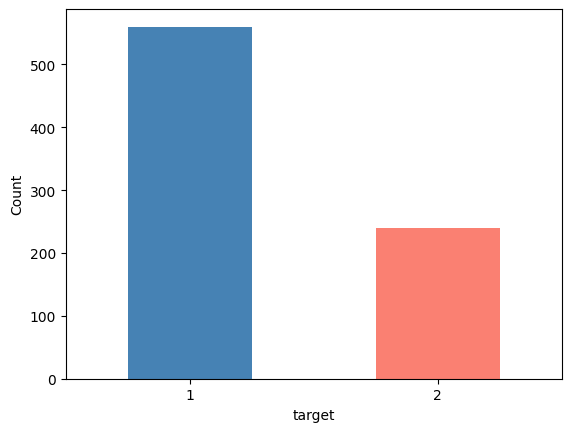

Sex distribution (baseline skew)


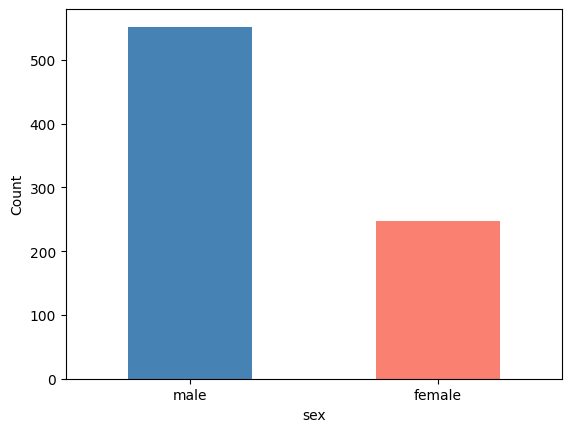

Sex distribution (%):
sex
male      69.0
female    31.0
Name: proportion, dtype: float64


<Figure size 640x480 with 0 Axes>

In [ ]:
# Class imbalance visualization
print("Target class distribution")
train_real["target"].value_counts().plot(kind="bar", color=["steelblue", "salmon"])
# plt.title("Target class distribution") remove title for latex(use latex caption, begin)
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()
plt.savefig("/content/drive/MyDrive/Thesis/figures/EDA/Target class distribution.pdf")

# Sex distribution skew
print("Sex distribution (baseline skew)")
train_real["sex"].value_counts().plot(kind="bar", color=["steelblue", "salmon"])
# plt.title("Sex distribution (baseline skew)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()
plt.savefig("/content/drive/MyDrive/Thesis/figures/EDA/Sex distribution (baseline skew).pdf")

print("Sex distribution (%):")
print(train_real["sex"].value_counts(normalize=True).round(3) * 100)

Age group distribution:
age_group
adult (≥25)    673
young (<25)    127
Name: count, dtype: int64
Target distribution by age group


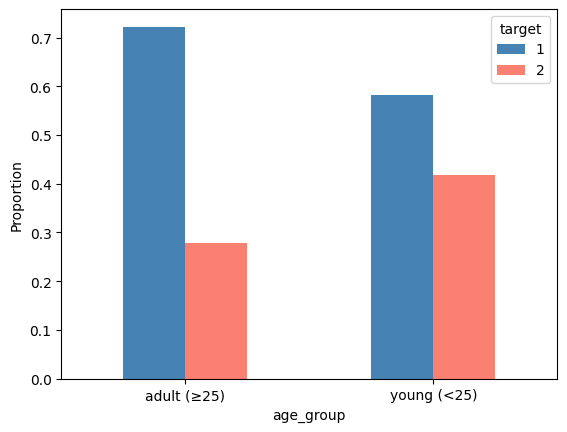

<Figure size 640x480 with 0 Axes>

In [ ]:
# Binarize age for fairness metric alignment where less than 25 is considered Young
train_real["age_group"] = (train_real["age"] < 25).map({True: "young (<25)", False: "adult (≥25)"})

print("Age group distribution:")
print(train_real["age_group"].value_counts())

pd.crosstab(train_real["age_group"], train_real["target"], normalize="index") \
    .plot(kind="bar", color=["steelblue", "salmon"])
print("Target distribution by age group")
# plt.title("Target distribution by age group")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()
plt.savefig("/content/drive/MyDrive/Thesis/figures/EDA/Target distribution by age group.pdf")

In [ ]:
# Summary statistics split by sensitive group
print("=== Mean numeric features by sex ===")
print(train_real.groupby("sex")[["credit_amount", "duration_months", "age"]].mean().round(2))

print("\n=== Mean numeric features by age group ===")
print(train_real.groupby("age_group")[["credit_amount", "duration_months"]].mean().round(2))

=== Mean numeric features by sex ===
        credit_amount  duration_months    age
sex                                          
female        2856.11            19.50  32.55
male          3443.91            21.64  36.80

=== Mean numeric features by age group ===
             credit_amount  duration_months
age_group                                  
adult (≥25)        3354.19            21.11
young (<25)        2771.55            20.28


Target distribution by sex


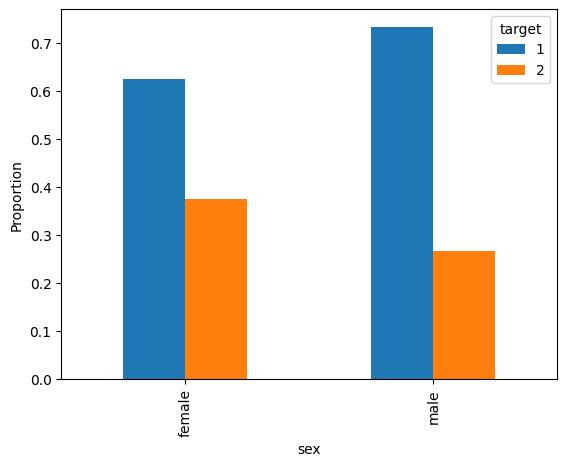

<Figure size 640x480 with 0 Axes>

In [ ]:
pd.crosstab(train_real["sex"], train_real["target"], normalize="index").plot(kind="bar")
print("Target distribution by sex")
# plt.title("Target distribution by sex")
plt.ylabel("Proportion")
plt.show()
plt.savefig("/content/drive/MyDrive/Thesis/figures/EDA/Target distribution by sex.pdf")

Target distribution based on foreign worker status


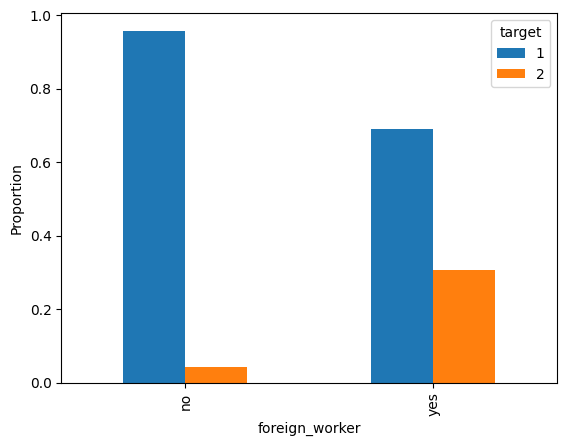

<Figure size 640x480 with 0 Axes>

In [ ]:
# split based on nationalty
pd.crosstab(train_real["foreign_worker"], train_real["target"], normalize="index").plot(kind="bar")

print("Target distribution based on foreign worker status")
# plt.title("Target distribution by nationality")
plt.ylabel("Proportion")
plt.show()
plt.savefig("/content/drive/MyDrive/Thesis/figures/EDA/Target distribution based on foreign worker status.pdf")

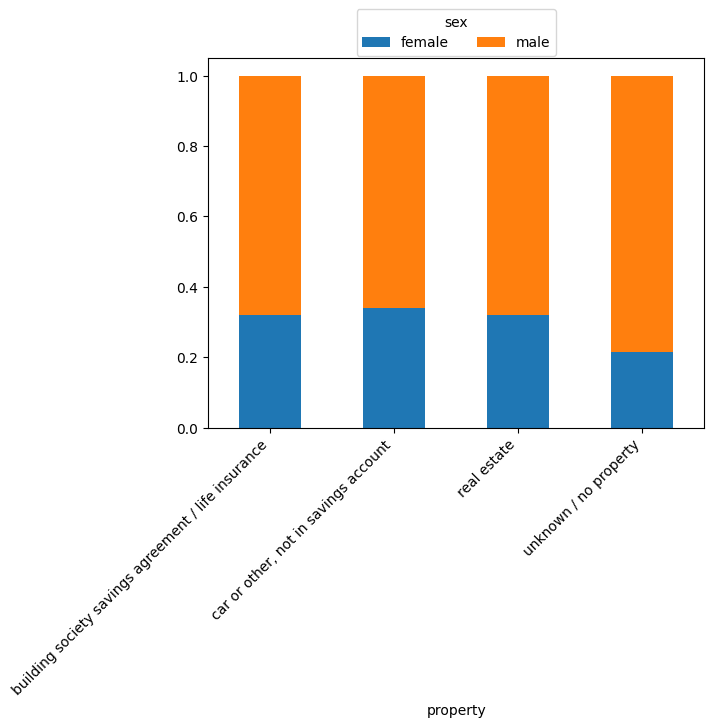

In [ ]:
pd.crosstab(train_real["property"], train_real["sex"], normalize="index")
pd.crosstab(train_real["property"], train_real["sex"], normalize="index").plot(kind="bar", stacked=True).legend(title="sex", loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)
plt.xticks(rotation=45, ha='right')
plt.savefig("/content/drive/MyDrive/Thesis/figures/EDA/Property ownership based on sex.pdf")

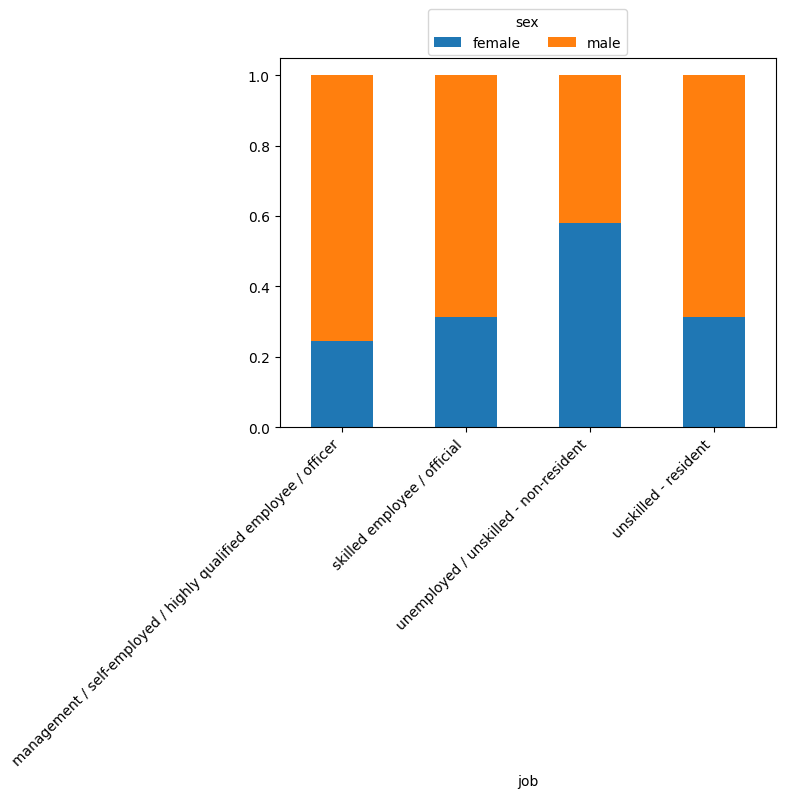

In [ ]:
pd.crosstab(train_real["job"], train_real["sex"], normalize="index")
pd.crosstab(train_real["job"], train_real["sex"], normalize="index").plot(kind="bar", stacked=True).legend(title="sex", loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)
plt.xticks(rotation=45, ha='right')
plt.savefig("/content/drive/MyDrive/Thesis/figures/EDA/Job distribution based on sex.pdf")

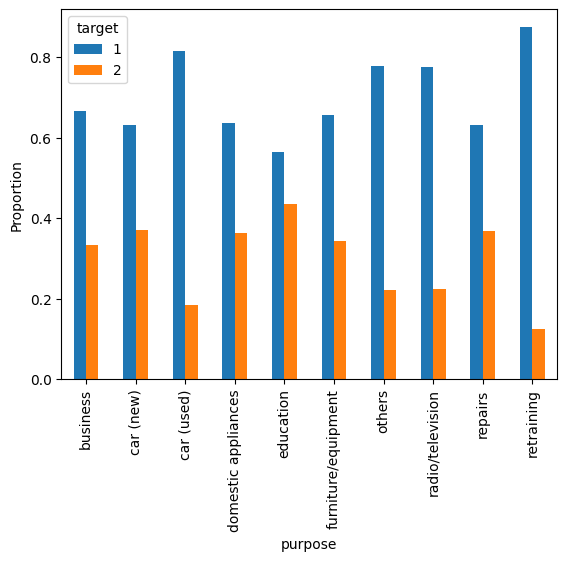

<Figure size 640x480 with 0 Axes>

In [ ]:
pd.crosstab(train_real["purpose"], train_real["target"], normalize="index") \
    .plot(kind="bar")

# plt.title("Target distribution by reason")
plt.ylabel("Proportion")
plt.show()
plt.savefig("/content/drive/MyDrive/Thesis/figures/EDA/Target distribution by loan purpose.pdf")

<Axes: title={'center': 'duration_months'}, xlabel='target'>

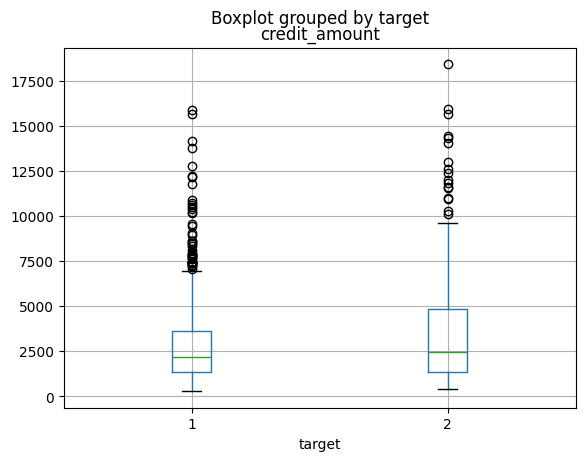

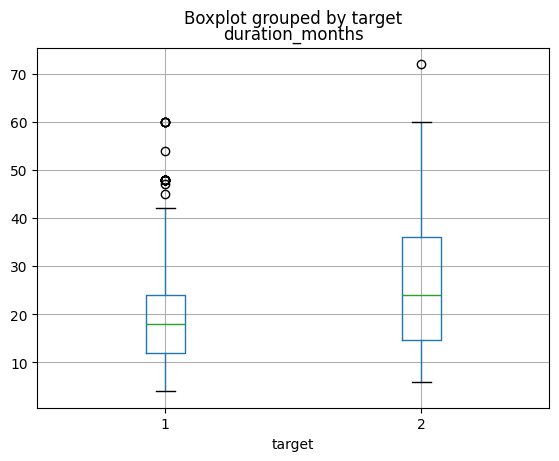

In [ ]:
# financial side(nothing to see)
train_real.boxplot(column="credit_amount", by="target")
train_real.boxplot(column="duration_months", by="target")

In [ ]:
# Cramér's V between categorical features and sensitive attributes
# from scipy.stats import chi2_contingency
# import numpy as np

# def cramers_v(x, y):
#     ct = pd.crosstab(x, y)
#     chi2 = chi2_contingency(ct)[0]
#     n = ct.sum().sum()
#     r, k = ct.shape
#     return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# cat_cols = ["credit_history", "purpose", "checking_account_status",
#             "savings_account", "employment_duration", "property"]

# print("Cramér's V with sex:")
# for col in cat_cols:
#     print(f"  {col}: {cramers_v(train_real[col], train_real['sex']):.3f}")

# print("\nCramér's V with age_group:")
# for col in cat_cols:
#     print(f"  {col}: {cramers_v(train_real[col], train_real['age_group']):.3f}")

# # Point-biserial correlation for numeric features vs age (continuous)
# from scipy.stats import pointbiserialr
# num_cols = ["credit_amount", "duration_months", "installment_rate"]
# sex_binary = (train_real["sex"] == "male").astype(int)

# print("\nPoint-biserial correlation with sex (binary):")
# for col in num_cols:
#     r, p = pointbiserialr(sex_binary, train_real[col])
#     print(f"  {col}: r={r:.3f}, p={p:.3f}")

Cramér's V with sex:
  credit_history: 0.123
  purpose: 0.129
  checking_account_status: 0.043
  savings_account: 0.047
  employment_duration: 0.240
  property: 0.103

Cramér's V with age_group:
  credit_history: 0.191
  purpose: 0.164
  checking_account_status: 0.160
  savings_account: 0.060
  employment_duration: 0.211
  property: 0.097

Point-biserial correlation with sex (binary):
  credit_amount: r=0.075, p=0.033
  duration_months: r=0.080, p=0.023
  installment_rate: r=0.106, p=0.003
